In [71]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import KFold, GridSearchCV
from scipy.integrate import ode

plt.rcParams.update({'font.size': 12})

- Funkcije

In [34]:
def integratorLorenz63(
        X0, Y0, Z0, integration_time,
        sigma=10., b = 8./3, r=28.
        ):
    """
    Integracija Lorenzovega '63 modela
    Args:
    - X0, Y0, Z0 = X(t=0), Y(t=0), Z(t=0) -> začetni pogoji
    - integration_time -> 1 enota = 100 korakov pri dt=0.01
    - sigma, b, r -> konstante sistema enačb
    """

    # Funkcija za integracijo: parcialno X/parcialno tau
    def f(t, X):
        # Desna stran Lorenz '63 sistema
        return [sigma*(X[1]-X[0]),
                X[0]*(r-X[2])-X[1],
                X[0]*X[1]-b*X[2]]
    
    def jac(t, X):
    # Jakobian sistema
        return [[-sigma, sigma, 0],
                [r-X[2], X*(r-X[2])-1, -X[0]],
                [X[1], X[0], -b]]
    
    # Integrator Runge-Kutta reda (4)5
    Integrator = ode(f, jac).set_integrator('dopri5')

    # Začetni pogoj za integracijo
    X0 = [X0, Y0, Z0] # Pozor - tu redefiniramo X0
    t0 = 0
    Integrator.set_initial_value(X0, t0)

    # Časovni korak integracije
    dt = 0.01

    # Tabeli za shranjevanje rezultatov integracije
    t = [0.]
    X = [X0]

    # Integracija
    while Integrator.successful() and Integrator.t+dt < integration_time:
        t.append(float(Integrator.t+dt))
        X.append(list(Integrator.integrate(Integrator.t+dt)))
        
    return np.array(t), np.array(X)


# Sekvenciranje multivariatnega zaporedja
def split_into_sequences(
        multivariate_sequence, input_seq_len,
        start_every_num_steps=8):
    """
    multivariate_sequence: shape (T, d); T=# čas. korakov, d=# dimenzij
    input_seq_len: dolžina vhodnega zaporedja
    start_every_num_steps: koliko časovnih korakov izpustimo,
    preden shranimo novo sekvenco
    """

    X, y = list(), list()
    
    # Zanka skozi vse časovne korake
    for i in range(0, len(multivariate_sequence), start_every_num_steps):

        # Zadnji indeks sekvence
        end_ix = i + input_seq_len

        # Preveri če je zadnji indeks izven multivariate_sequence
        if end_ix > len(multivariate_sequence)-1:
            break

        # seq_x je sestavljena iz input_seq_len korakov
        seq_x = multivariate_sequence[i:end_ix, :]
        # seq_y je samo 1 element za napoved
        seq_y = multivariate_sequence[end_ix, :]

        X.append(seq_x)
        y.append(seq_y)

    return np.array(X), np.array(y)


# Custom layer for Luong Attention
@tf.keras.utils.register_keras_serializable()
class LuongAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(LuongAttention, self).__init__(**kwargs)
    
    def call(self, decoder_hidden, encoder_outputs):
        # Izračun skalarnega produkta med skritim stanjem dekodirnika
        # in skritimi stanji kodirnika. V ta namen za vsak primer v batchu
        # množimo matriko z vrsticami skritih stanj kodirnika s
        # transponirano matriko skritih stanj dekodirnika (tf.matmul).
        score = tf.matmul(encoder_outputs, decoder_hidden, transpose_b=True)
        # shape = (batch_size, time_steps_encoder, time_steps_decoder=1)

        # Izračunamo uteži pozornosti - softmax po osi kodirnih skritih stanj
        attention_weights = tf.nn.softmax(score, axis=1)
        # shape = (batch_size, time_steps_encoder, time_steps_decoder=1)

        # Vektor konteksta je s pozornostjo utežena linearna kombinacija
        # izhodov kodirnika.
        context_vector = tf.reduce_sum(
                    attention_weights * encoder_outputs, axis=1)
        # shape = (batch_size, hidden_size)

        return context_vector, attention_weights
    

def create_SimpleRNN_model():
    """
    Creates a SimpleRNN model
    """
    model = tf.keras.models.Sequential()
    model.add(SimpleRNN(
        units=16, # dimenzija skritega stanja
        return_sequences=False,
        input_shape=(None,3))
        )
    # ekvivalent za LSTM: model.add(LSTM(...))
    # Zadnje skrito stanje še preslikamo v izhodni vektor y
    model.add(Dense(3))
    # Nastavitve za učenje modela
    model.compile(loss='mean_squared_error', optimizer='Adam')
    return model


def create_Luong_attention_model():
    """
    Creates a model with Luong attention vector.
    """
    
    """   KODIRNIK   """
    # Vhodni tenzor za kodirnik
    encoder_inputs = tf.keras.Input(shape=(None, 3))
    # Kodirni sloj
    encoder_lstm = layers.LSTM(
        units=16, # Število dimenzij skritega stanja
        return_sequences=True, # Vrni vsa skrita stanja
        return_state=True, # Vrni zadnje celično stanje
        name='encoder' # Sloj poimenujemo za kasnejšo rabo
    )
    
    # Pošlji vhodni tenzor kodirnika skozi kodirnik
    encoder_hidden_states, state_h, state_c = encoder_lstm(encoder_inputs)
    # encoder_hidden_states shape: # (batch_size, encoder_time_steps, hidden_size)
    
    
    """   DEKODIRNIK   """
    # Vhodni tenzor za dekodirnik
    decoder_inputs = tf.keras.Input(shape=(None, 3))
    # Dekodirni sloj
    decoder_lstm = layers.LSTM(
        units=16, # Število dimenzij skritega stanja
        return_sequences=True, # Vrni vsa skrita stanja
        return_state=True, # Vrni zadnje celično stanje
        name='decoder' # Sloj poimenujemo za kasnejšo rabo
    )
    
    # Nastavi začetno skrito in celično stanje dekodirnika
    # in pošlji vhodni tenzor dekodirnika skozi dekodirnik
    decoder_hidden_states, _, _ = decoder_lstm(
        decoder_inputs, initial_state=[state_h, state_c])
    # decoder_hidden_states shape: # (batch_size, decoder_time_steps, hidden_size)
    
    
    """   Luongov mehanizem pozornosti (Luong Attention)   """
    attention_layer = LuongAttention()
    context_vector, attention_weights = attention_layer(
        decoder_hidden_states, encoder_hidden_states)
    
    # Konkateniramo vektorje konteksta s skritimi stanji dekoderja
    # combined_context = layers.Concatenate(axis=-1)(
    #     [decoder_hidden_states, tf.expand_dims(context_vector, 1)])
    
    context_vector_exp = layers.Reshape((1, 16))(context_vector)
    combined_context = layers.Concatenate(axis=-1)([decoder_hidden_states, context_vector_exp])

    # Konkatenirane vektorje preslikamo v nova skrita stanja, tako da
    # jih pošljemo skozi gosto povezano NN. V ta namen uporabimo sloj
    # TimeDistributed, ki aplicira uteži na vse izhode.
    new_decoder_hidden_states = layers.TimeDistributed(
        layers.Dense(units=16, activation="tanh"))(combined_context)
    # Nova skrita stanja z gosto povezano NN preslikamo v izhode.

    outputs = layers.TimeDistributed(
        layers.Dense(3))(new_decoder_hidden_states)
    # Ustvarimo model (funkcijo oz. računski graf), tako da definiramo

    # vhodna in izhodna polja.
    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs = outputs)

    # Konfiguriramo nastavitve za učenje
    model.compile(loss='mean_squared_error', optimizer='Adam')

    return model


def run_KFold(model, X, Y, n_splits, save_path):
    """
    Runs KFold for a chosen model
    """
    os.makedirs(save_path, exist_ok=True)

    # Callbacks 
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=8,
        min_lr=1e-4
    )

    kf = KFold(n_splits)
    histories = []
    scores_MSE = []
    fold = 1

    for train_idx, test_idx in kf.split(X, Y):

        print(f"Training fold {fold}...")
        
        if model == "SimpleRNN":
            model = create_SimpleRNN_model()
        else:
            model = create_Luong_attention_model()

        model_path = os.path.join(save_path, f"model_fold_{fold}.keras")

        # Callback
        checkpoint = tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,   # shrani cel model (struktura + uteži)
            verbose=0
        )

        history = model.fit(
            X[train_idx], Y[train_idx],
            epochs=200,
            batch_size=100,
            verbose=0,
            validation_split=0.1,
            shuffle=True,
            callbacks=[early_stop, checkpoint, reduce_lr]
        )

        histories.append(history)

        best_model = tf.keras.models.load_model(model_path)

        mse = best_model.evaluate(X[test_idx], Y[test_idx], verbose=0)

        scores_MSE.append(mse)

        print(f" Fold {fold} → MSE = {mse:.4f}")
        fold += 1

    # -----------------------------
    # Rezultati
    # -----------------------------
    print("\n============================")
    print("FINAL RESULTS OVER ALL FOLDS")
    print("============================")

    print(f"Average MSE: {np.mean(scores_MSE):.4f} ± {np.std(scores_MSE):.4f}")

    return scores_MSE, histories


def napoved(N, model, input_seq_len, X_ics_norm, scaler, Luong_attention=False):
    """
    Funkcija za izračun modelskih napovedi
    args:
    - N: število začetnih pogojev
    - model: rekurentni model brez Luongove pozornosti
    model = tf.keras.models.load_model(path_model)
    - input_seq_len: dolžina vhodne sekvence v model
    - Luong_attention (bool): True, če imamo model z Luongovo pozornostjo
    """
    
    # Priprava vhodnega tenzorja
    X_start = np.expand_dims(X_ics_norm[:,-input_seq_len], axis=1)
    for j in range(input_seq_len-1, 0, -1):
        X_start = np.append(
        X_start, np.expand_dims(X_ics_norm[:,-j], axis=1),
        axis=1
        )
    
    # Tabela za zapisovanje napovedi - prva vrednost je začetni pogoj
    pred = X_start[:,-1:]
    
    if Luong_attention:
        start_token = X_start[:,-1:]
    
    # Izvedba napovedi za 10 enot časa
    T = [0.]

    for t in range(10*100):
        if Luong_attention == False:
            # Brez Luongove pozornosti:
            next_step = model.predict(X_start)
            next_step = np.expand_dims(next_step, axis=1)
            pred = np.append(pred, next_step, axis=1)
            X_start = np.concatenate((X_start[:,1:], next_step), axis=1)
        else:
            next_step = model.predict([X_start, start_token])
            pred = np.append(pred, next_step, axis=1)
            X_start = np.concatenate((X_start[:,1:], next_step), axis=1)
            start_token = X_start[:, -1:]

        # Napovedi reskaliramo v osnovno velikost
        predictions = []

        for i in range(N):
            predictions.append(scaler.inverse_transform(pred[i,:,:]))
        T.append((t+1)*0.01)

    return np.array(T), np.array(predictions)

## Priprava podatkov

In [35]:
""" Učni ter validacijski podatki """

# Za ponovljivost določimo seme
np.random.seed(42)

#Začetni pogoj za učno trajektorijo
X0_train = float(np.random.uniform(low=-50., high = 50., size = 1))
Y0_train = float(np.random.uniform(low=-50., high = 50., size = 1))
Z0_train = float(np.random.uniform(low=-50., high = 50., size = 1))

# Čas integracije
t_train = 8030. # Prvih 30 enot časa bomo odstranili

# Numerična integracija
t_train, data_train = integratorLorenz63(
    X0_train, Y0_train, Z0_train,
    t_train)

# Odrežemo prvih 30 enot časa - da ohranimo le točke na atraktorju
relaksacijski_indeks = 3000
data_train = np.array(data_train)[relaksacijski_indeks:, :]

# Podatke razdelimo na učno in validacijsko množico
# 90 % za učenje, 10 % za validacijo
split_idx = int(0.1 * len(data_train))

X_val = data_train[:split_idx]
X_train = data_train[split_idx:]

# Uporabimo standardizacijo (opcija je tudi MinMaxScaler)
scaler = StandardScaler()
# Povprečje in std izračunamo na učni množici (ne na validacijski)!
scaler.fit(X_train)

# Izpiši povprečno vrednost in standardno deviacijo
print("Povprečje:", scaler.mean_)
print("Standardna deviacija:", scaler.scale_)

# Normiramo podatke
X_train_norm = scaler.transform(X_train)
X_val_norm = scaler.transform(X_val)

input_seq_len = 5
# Učni podatki
X1_train, Y1_train = split_into_sequences(X_train_norm, input_seq_len)
# Validacijski podatki
X1_val, Y1_val = split_into_sequences(X_val_norm, input_seq_len)

C:\Users\tadej\AppData\Local\Temp\ipykernel_13672\2448391325.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X0_train = float(np.random.uniform(low=-50., high = 50., size = 1))
C:\Users\tadej\AppData\Local\Temp\ipykernel_13672\2448391325.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y0_train = float(np.random.uniform(low=-50., high = 50., size = 1))
C:\Users\tadej\AppData\Local\Temp\ipykernel_13672\2448391325.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.2

Povprečje: [-0.03917021 -0.0391126  23.55120557]
Standardna deviacija: [7.92470512 9.01091533 8.62086367]


In [36]:
""" Testni podatki """

# Število začetnih pogojev
N = 200

# Seme za ponovljivost eksperimenta
np.random.seed(10043)

# Začetni pogoji za učno trajektorijo
X0_test = float(np.random.uniform(low=-50., high = 50., size = 1))
Y0_test = float(np.random.uniform(low=-50., high = 50., size = 1))
Z0_test = float(np.random.uniform(low=-50., high = 50., size = 1))

# Čas integracije
t_test = 30.0 + N
# Numerična integracija
t_test, X_test = integratorLorenz63(X0_test, Y0_test, Z0_test, t_test)

# Relaksacija: odrežemo prvih 30.0 enot časa
relaksacijski_indeks = 3001 # 1, ker je vključen tudi začetni pogoj
X_test = X_test[relaksacijski_indeks:, :]

# Pripravimo začetne pogoje (ics=initial conditions)
X_ics = X_test[:N*100].reshape(N, 100, 3)
# Normiramo začetne pogoje
X_ics_norm = scaler.transform(X_test)[:N*100].reshape(N, 100, 3)
# X_ics(_norm).shape: (N, 100, 3)

C:\Users\tadej\AppData\Local\Temp\ipykernel_13672\960818173.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X0_test = float(np.random.uniform(low=-50., high = 50., size = 1))
C:\Users\tadej\AppData\Local\Temp\ipykernel_13672\960818173.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y0_test = float(np.random.uniform(low=-50., high = 50., size = 1))
C:\Users\tadej\AppData\Local\Temp\ipykernel_13672\960818173.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.

## SimpleRNN mreža

In [45]:
""" Trening SimpleRNN mreže """

modelRNN = create_SimpleRNN_model()

# Callbacks 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=8,
    min_lr=1e-4
)

fitRNN = modelRNN.fit(
    x=X1_train,
    y=Y1_train,
    batch_size=300,
    epochs=1000,
    validation_data=(X1_val, Y1_val),
    callbacks=[reduce_lr, early_stop],
    shuffle=True)

modelRNN.save('modelRNN.keras')

Epoch 1/1000


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0748 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 3/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 4/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011 - val_loss: 9.1385e-04 - learning_rate: 0.0010
Epoch 5/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.1598e-04 - val_loss: 6.0958e-04 - learning_rate: 0.0010
Epoch 6/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.8607e-04 - val_loss: 4.2417e-04 - learning_rate: 0.0010
Epoch 7/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4059e-04 - val_loss: 3.0265e-04 - learning_rate: 0.0010
Epoch 8/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4518e-04 - val_loss: 2.2348e-04 - learning_rate: 0.0010
Epoch 9/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7989e-04 - val_lo

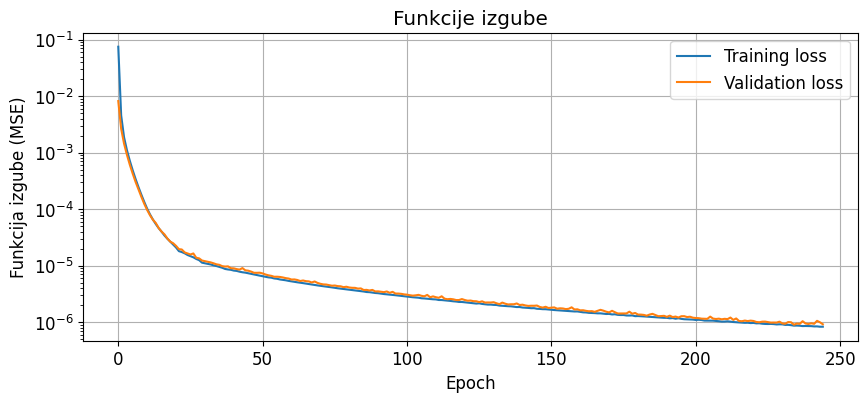

In [46]:
""" Loss function """
history = fitRNN.history

plt.figure(figsize=(10, 4))
plt.plot(history['loss'], label='Training loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Funkcija izgube (MSE)')
plt.title('Funkcije izgube')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
""" Predikcije """

model = tf.keras.models.load_model("modelRNN.keras")

ts, pred = napoved(N, model, input_seq_len, X_ics_norm, scaler) # Napovedi

X_true = np.zeros_like(pred) # Realne vrednosti
for i in range(N):
    _, X_true[i] = integratorLorenz63(*tuple(pred[i, 0, :]), ts[-1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━

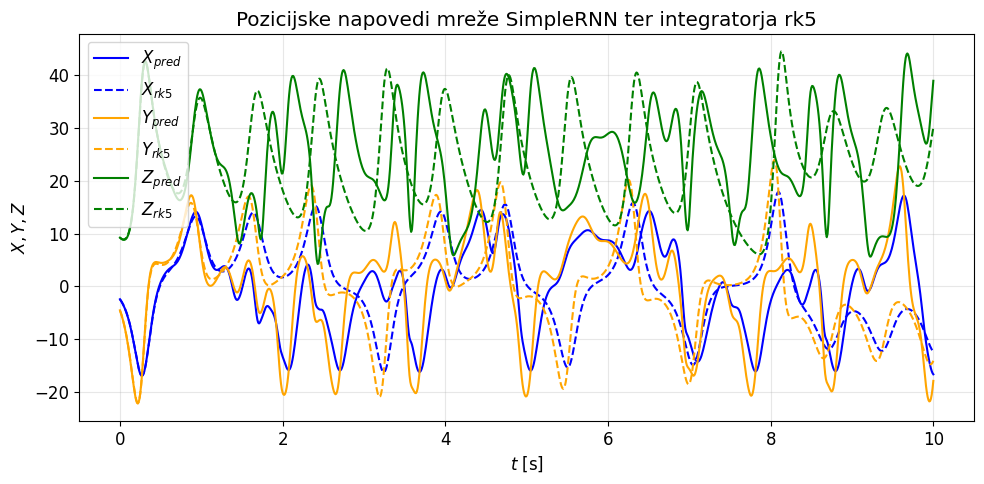

In [61]:
""" Plottane predikcije in realne vrednosti """

plt.figure(figsize=(10, 5))
plt.title('Pozicijske napovedi mreže SimpleRNN ter integratorja rk5')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$X, Y, Z$')
plt.grid(alpha=0.3)
plt.plot(ts, pred[11, :, 0], c='blue', label=r'$X_{pred}$')
plt.plot(ts, X_true[11, :, 0], c='blue', ls='--', label=r'$X_{rk5}$')
plt.plot(ts, pred[11, :, 1], c='orange', label=r'$Y_{pred}$')
plt.plot(ts, X_true[11, :, 1], c='orange', ls='--', label=r'$Y_{rk5}$')
plt.plot(ts, pred[11, :, 2], c='green', label=r'$Z_{pred}$')
plt.plot(ts, X_true[11, :, 2], c='green', ls='--', label=r'$Z_{rk5}$')
plt.legend()
plt.tight_layout()
plt.show()

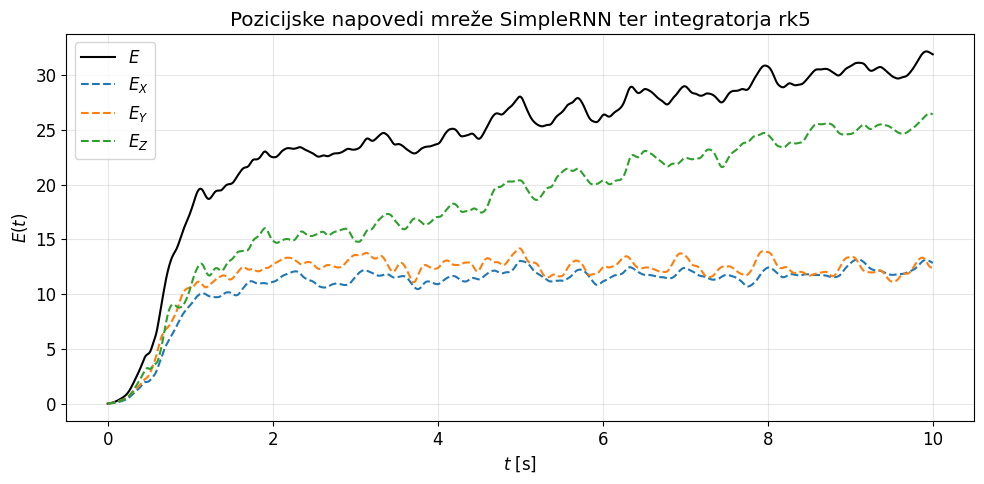

In [62]:
""" Napaka predikcije """

errRNN = np.sqrt(np.sum((pred - X_true)**2, axis=(0, 2)) / N)
errRNN_XYZ = np.sqrt(np.sum((pred - X_true)**2, axis=0) / N)

plt.figure(figsize=(10, 5))
plt.title('Pozicijske napovedi mreže SimpleRNN ter integratorja rk5')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$E (t)$')
plt.grid(alpha=0.3)
plt.plot(ts, errRNN, c='black', label=r'$E$')
plt.plot(ts, errRNN_XYZ[:, 0], ls='--', label=r'$E_X$')
plt.plot(ts, errRNN_XYZ[:, 1], ls='--', label=r'$E_Y$')
plt.plot(ts, errRNN_XYZ[:, 2], ls='--', label=r'$E_Z$')
plt.legend()
plt.tight_layout()
plt.show()

## Luongova pozornost

In [64]:
""" Trening Luong attention mreže """

modelLuong = create_Luong_attention_model()

# Callbacks 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=8,
    min_lr=1e-4
)

fitLuong = modelLuong.fit(
    x=[X1_train, X1_train[:,-1:]],
    y=np.expand_dims(Y1_train, axis=1),
    batch_size=300,
    epochs=500,
    validation_data=([X1_val, X1_val[:,-1:]], np.expand_dims(Y1_val, axis=1)),
    callbacks=[reduce_lr, early_stop],
    shuffle=True)

modelLuong.save('modelLuong.keras')

Epoch 1/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1102 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 2/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 3/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.1379e-04 - val_loss: 5.7160e-04 - learning_rate: 0.0010
Epoch 4/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0982e-04 - val_loss: 3.2969e-04 - learning_rate: 0.0010
Epoch 5/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4558e-04 - val_loss: 2.0805e-04 - learning_rate: 0.0010
Epoch 6/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5550e-04 - val_loss: 1.3343e-04 - learning_rate: 0.0010
Epoch 7/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.9759e-05 - val_loss: 8.6570e-05 - learning_rate: 0.0010
Epoch 8/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4172e-05 - val_loss: 5.7746e-05 - learning_rate: 0.0010
Epoch 9/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.2

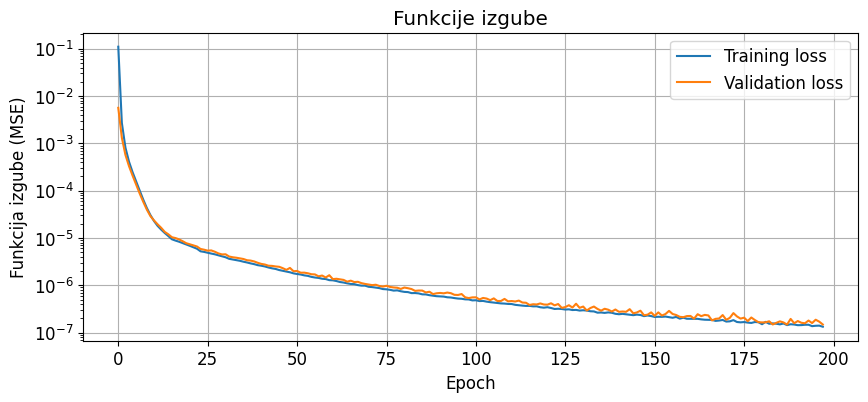

In [65]:
""" Loss function """

# History
history = fitLuong.history

plt.figure(figsize=(10, 4))
plt.plot(history['loss'], label='Training loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Funkcija izgube (MSE)')
plt.title('Funkcije izgube')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
""" Predikcije """

model = tf.keras.models.load_model(
    "modelLuong.keras",
    custom_objects={"LuongAttention": LuongAttention},
    safe_mode=False
)

ts, pred = napoved(N, model, input_seq_len, X_ics_norm, scaler, Luong_attention=True)

X_true = np.zeros_like(pred)
for i in range(N):
    _, X_true[i] = integratorLorenz63(*tuple(pred[i, 0, :]), ts[-1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━

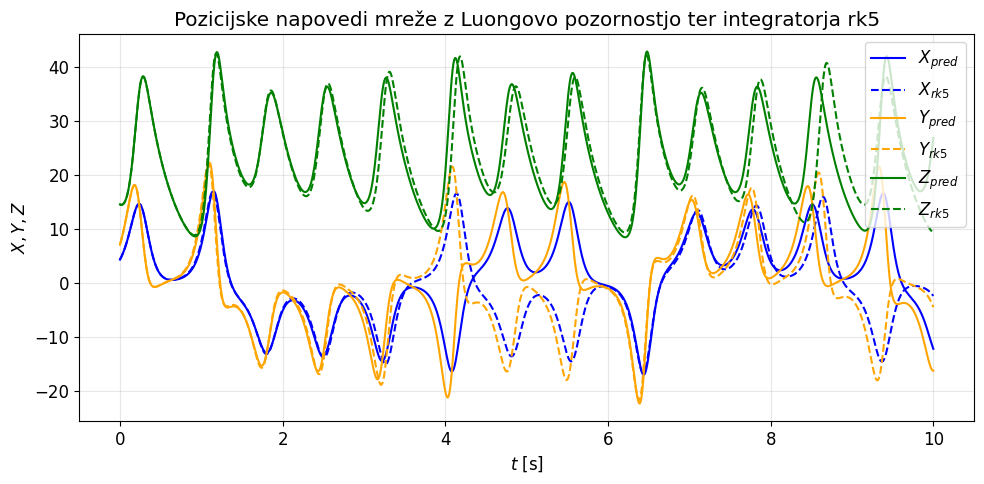

In [67]:
plt.figure(figsize=(10, 5))
plt.title('Pozicijske napovedi mreže z Luongovo pozornostjo ter integratorja rk5')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$X, Y, Z$')
plt.grid(alpha=0.3)
plt.plot(ts, pred[1, :, 0], c='blue', label=r'$X_{pred}$')
plt.plot(ts, X_true[1, :, 0], c='blue', ls='--', label=r'$X_{rk5}$')
plt.plot(ts, pred[1, :, 1], c='orange', label=r'$Y_{pred}$')
plt.plot(ts, X_true[1, :, 1], c='orange', ls='--', label=r'$Y_{rk5}$')
plt.plot(ts, pred[1, :, 2], c='green', label=r'$Z_{pred}$')
plt.plot(ts, X_true[1, :, 2], c='green', ls='--', label=r'$Z_{rk5}$')
plt.legend()
plt.tight_layout()
plt.show()

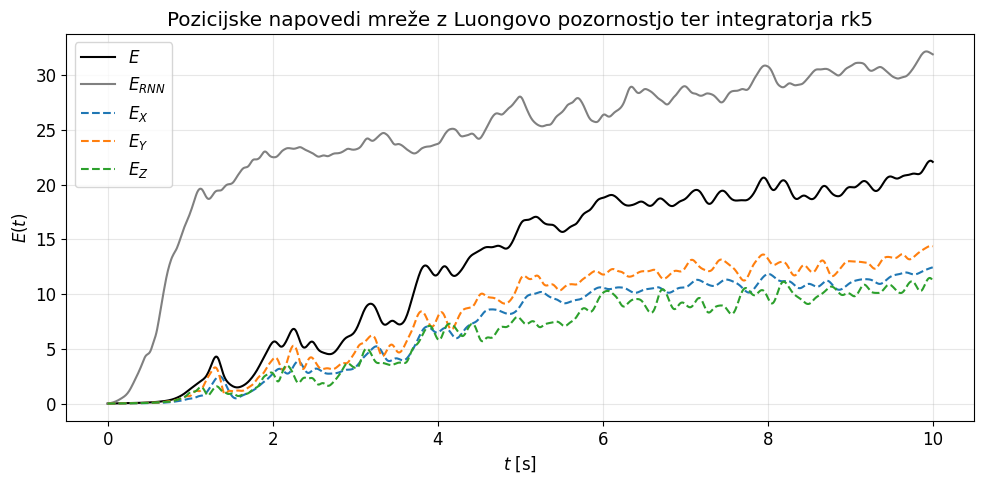

In [70]:
errLuong = np.sqrt(np.sum((pred - X_true)**2, axis=(0, 2)) / N)
errLuong_XYZ = np.sqrt(np.sum((pred - X_true)**2, axis=0) / N)

plt.figure(figsize=(10, 5))
plt.title('Pozicijske napovedi mreže z Luongovo pozornostjo ter integratorja rk5')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$E (t)$')
plt.grid(alpha=0.3)
plt.plot(ts, errLuong, c='black', label=r'$E$')
plt.plot(ts, errRNN, c='Gray', label=r'$E_{RNN}$')
plt.plot(ts, errLuong_XYZ[:, 0], ls='--', label=r'$E_X$')
plt.plot(ts, errLuong_XYZ[:, 1], ls='--', label=r'$E_Y$')
plt.plot(ts, errLuong_XYZ[:, 2], ls='--', label=r'$E_Z$')
plt.legend()
plt.tight_layout()
plt.show()

### Iskanje optimalnih parametrov mreže z Luongovo pozornostjo

In [ ]:
def create_Luong_attention_model_grid_search(hidden_units):
    """
    Creates a model with Luong attention vector.
    """
    
    """   KODIRNIK   """
    # Vhodni tenzor za kodirnik
    encoder_inputs = tf.keras.Input(shape=(None, 3))
    # Kodirni sloj
    encoder_lstm = layers.LSTM(
        units=hidden_units, # Število dimenzij skritega stanja
        return_sequences=True, # Vrni vsa skrita stanja
        return_state=True, # Vrni zadnje celično stanje
        name='encoder' # Sloj poimenujemo za kasnejšo rabo
    )
    
    # Pošlji vhodni tenzor kodirnika skozi kodirnik
    encoder_hidden_states, state_h, state_c = encoder_lstm(encoder_inputs)
    # encoder_hidden_states shape: # (batch_size, encoder_time_steps, hidden_size)
    
    
    """   DEKODIRNIK   """
    # Vhodni tenzor za dekodirnik
    decoder_inputs = tf.keras.Input(shape=(None, 3))
    # Dekodirni sloj
    decoder_lstm = layers.LSTM(
        units=hidden_units, # Število dimenzij skritega stanja
        return_sequences=True, # Vrni vsa skrita stanja
        return_state=True, # Vrni zadnje celično stanje
        name='decoder' # Sloj poimenujemo za kasnejšo rabo
    )
    
    # Nastavi začetno skrito in celično stanje dekodirnika
    # in pošlji vhodni tenzor dekodirnika skozi dekodirnik
    decoder_hidden_states, _, _ = decoder_lstm(
        decoder_inputs, initial_state=[state_h, state_c])
    # decoder_hidden_states shape: # (batch_size, decoder_time_steps, hidden_size)
    
    
    """   Luongov mehanizem pozornosti (Luong Attention)   """
    attention_layer = LuongAttention()
    context_vector, attention_weights = attention_layer(
        decoder_hidden_states, encoder_hidden_states)
    
    context_vector_exp = layers.Reshape((1, hidden_units))(context_vector)
    combined_context = layers.Concatenate(axis=-1)([decoder_hidden_states, context_vector_exp])

    # Konkatenirane vektorje preslikamo v nova skrita stanja, tako da
    # jih pošljemo skozi gosto povezano NN. V ta namen uporabimo sloj
    # TimeDistributed, ki aplicira uteži na vse izhode.
    new_decoder_hidden_states = layers.TimeDistributed(
        layers.Dense(units=hidden_units, activation="tanh"))(combined_context)
    # Nova skrita stanja z gosto povezano NN preslikamo v izhode.

    outputs = layers.TimeDistributed(
        layers.Dense(3))(new_decoder_hidden_states)
    # Ustvarimo model (funkcijo oz. računski graf), tako da definiramo

    # vhodna in izhodna polja.
    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs = outputs)

    # Konfiguriramo nastavitve za učenje
    model.compile(loss='mean_squared_error', optimizer='Adam')

    return model